In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")

SEED = 42
SAMPLE_SIZE = 150_000

COMMON_DROP_COLUMNS = [
    "tpep_pickup_datetime",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "Airport_fee",
    "congestion_surcharge",
    "cbd_congestion_fee",
    "avg_speed_mph",
    "tip_to_total_ratio",
    "is_extreme_fare",
    "cbd_fee_ratio",
    "total_surcharges",
    "surcharges_ratio",
    "base_fare_ratio",
    "store_and_fwd_encoded",
    "VendorID",
    "payment_type",
    "payment_name",
]

KNOWN_CATEGORICAL_COLUMNS = [
    "PULocationID",
    "DOLocationID",
    "RatecodeID",
    "pickup_hour",
    "pickup_day_of_week",
    "time_slot",
    "time_of_day",
    "pickup_borough",
    "dropoff_borough",
    "distance_category",
    "ratecode_name",
]


def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "processed" / "taxi_engineered.parquet").exists():
            return candidate
    raise FileNotFoundError("Could not find project root from the current working directory.")


def make_stratified_sample(frame, sample_size, stratify_col, random_state=SEED):
    if sample_size >= len(frame):
        return frame.copy()

    sampled_index, _ = train_test_split(
        frame.index,
        train_size=sample_size,
        stratify=frame[stratify_col],
        random_state=random_state,
    )
    return frame.loc[sampled_index].copy().sort_index()


def prepare_features(frame, target_name, extra_drop_columns):
    drop_columns = [target_name, *extra_drop_columns, *COMMON_DROP_COLUMNS]
    existing_drop_columns = [column for column in drop_columns if column in frame.columns]

    X = frame.drop(columns=existing_drop_columns).copy()
    y = frame[target_name].copy()

    detected_categorical = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    categorical_columns = sorted(
        set(detected_categorical).union(column for column in KNOWN_CATEGORICAL_COLUMNS if column in X.columns)
    )

    for column in categorical_columns:
        X[column] = X[column].astype("string").fillna("__MISSING__").astype("category")

    return X, y, categorical_columns


def group_error_summary(frame, group_col, order=None):
    summary = (
        frame.groupby(group_col)
        .agg(
            trips=("residual", "size"),
            mean_actual=("actual_duration_min", "mean"),
            mean_predicted=("predicted_duration_min", "mean"),
            mae=("abs_error", "mean"),
            rmse=("residual", lambda values: float(np.sqrt(np.mean(np.square(values))))),
            mean_residual=("residual", "mean"),
            median_abs_error=("abs_error", "median"),
        )
        .reset_index()
    )

    if order is not None:
        summary[group_col] = pd.Categorical(summary[group_col], categories=order, ordered=True)
        summary = summary.sort_values(group_col).reset_index(drop=True)
        summary[group_col] = summary[group_col].astype(str)

    return summary


## Rebuild the same advanced-model workflow

This notebook reuses the same sample size, dropped columns, categorical handling, train/validation/test split pattern, and XGBoost settings from `Tarun_XGB.ipynb`. Predictions were not saved separately in that notebook, so the minimum needed training code is included here to regenerate them for evaluation.


In [2]:
PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "taxi_engineered.parquet"

data = pd.read_parquet(DATA_PATH)
model_data = make_stratified_sample(
    frame=data,
    sample_size=SAMPLE_SIZE,
    stratify_col="has_congestion_fee",
    random_state=SEED,
)

X_duration, y_duration, duration_categorical_columns = prepare_features(
    frame=model_data,
    target_name="trip_duration_min",
    extra_drop_columns=["has_congestion_fee"],
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_duration,
    y_duration,
    test_size=0.20,
    random_state=SEED,
)
X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_train_d,
    y_train_d,
    test_size=0.20,
    random_state=SEED,
)

duration_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
)

duration_xgb.fit(
    X_train_d,
    y_train_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=False,
)

duration_pred = duration_xgb.predict(X_test_d)

context_columns = [
    "trip_distance",
    "pickup_hour",
    "pickup_day_of_week",
    "time_of_day",
    "is_rush_hour",
    "distance_category",
    "pickup_borough",
    "dropoff_borough",
    "is_airport_trip",
    "is_same_borough",
    "PULocationID",
    "DOLocationID",
    "RatecodeID",
]
available_context_columns = [column for column in context_columns if column in model_data.columns]

eval_results = model_data.loc[X_test_d.index, available_context_columns].copy()
eval_results["actual_duration_min"] = y_test_d
eval_results["predicted_duration_min"] = duration_pred
eval_results["residual"] = eval_results["actual_duration_min"] - eval_results["predicted_duration_min"]
eval_results["abs_error"] = eval_results["residual"].abs()

if "is_rush_hour" in eval_results.columns:
    eval_results["rush_hour_group"] = np.where(
        eval_results["is_rush_hour"] == 1,
        "Rush hour",
        "Non-rush hour",
    )
else:
    eval_results["rush_hour_group"] = np.where(
        eval_results["pickup_hour"].between(7, 9) | eval_results["pickup_hour"].between(17, 19),
        "Rush hour",
        "Non-rush hour",
    )

if "distance_category" in eval_results.columns:
    eval_results["trip_length_group"] = (
        eval_results["distance_category"].astype("string").fillna("unknown").astype(str)
    )
else:
    eval_results["trip_length_group"] = pd.cut(
        eval_results["trip_distance"],
        bins=[0, 2, 5, np.inf],
        labels=["short", "medium", "long"],
        include_lowest=True,
    ).astype(str)

if {"pickup_borough", "dropoff_borough"}.issubset(eval_results.columns):
    eval_results["borough_route"] = (
        eval_results["pickup_borough"].astype(str) + " -> " + eval_results["dropoff_borough"].astype(str)
    )

regression_metrics = {
    "MAE (minutes)": float(mean_absolute_error(y_test_d, duration_pred)),
    "RMSE (minutes)": float(np.sqrt(mean_squared_error(y_test_d, duration_pred))),
    "R^2": float(r2_score(y_test_d, duration_pred)),
    "Best validation RMSE": float(duration_xgb.best_score),
    "Best boosting round": int(duration_xgb.best_iteration),
}

rush_summary = group_error_summary(
    eval_results,
    "rush_hour_group",
    order=["Non-rush hour", "Rush hour"],
)
distance_summary = group_error_summary(
    eval_results,
    "trip_length_group",
    order=["short", "medium", "long", "unknown"],
)

worst_cases = (
    eval_results.sort_values("abs_error", ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"index": "row_id"})
)
worst20 = eval_results.sort_values("abs_error", ascending=False).head(20).copy()

print(f"Data path: {DATA_PATH}")
print(f"Sample size used for modeling: {len(model_data):,}")
print(f"Train / validation / test rows: {len(X_train_d):,} / {len(X_val_d):,} / {len(X_test_d):,}")
print(f"Features used by the regressor: {X_duration.shape[1]}")
print(f"Categorical columns handled by XGBoost: {len(duration_categorical_columns)}")


Data path: C:\Users\Tarun\OneDrive\Syracuse University\IST 707 - Applied Machine Learning\Group Project\group-project-avengers\group-project-avengers\data\processed\taxi_engineered.parquet
Sample size used for modeling: 150,000
Train / validation / test rows: 96,000 / 24,000 / 30,000
Features used by the regressor: 21
Categorical columns handled by XGBoost: 11


## Overall model fit


In [3]:
metrics_table = pd.DataFrame(
    {
        "Metric": list(regression_metrics.keys()),
        "Value": list(regression_metrics.values()),
    }
)

print(metrics_table.round(3).to_string(index=False))
print()
print(
    f"On this test split, the XGBoost model has an average absolute error of {regression_metrics['MAE (minutes)']:.2f} minutes "
    f"and an RMSE of {regression_metrics['RMSE (minutes)']:.2f} minutes. Its R^2 is {regression_metrics['R^2']:.3f}, "
    "so it explains most of the variation in trip duration on the held-out sample."
)
print("These overall numbers are strong, but averages can hide where the model still misses badly.")


              Metric   Value
       MAE (minutes)   2.502
      RMSE (minutes)   3.896
                 R^2   0.866
Best validation RMSE   3.916
 Best boosting round 423.000

On this test split, the XGBoost model has an average absolute error of 2.50 minutes and an RMSE of 3.90 minutes. Its R^2 is 0.866, so it explains most of the variation in trip duration on the held-out sample.
These overall numbers are strong, but averages can hide where the model still misses badly.


## Residual analysis

Residuals are defined here as:

`residual = actual trip time - predicted trip time`

So:
- A **positive** residual means the model predicted too low.
- A **negative** residual means the model predicted too high.


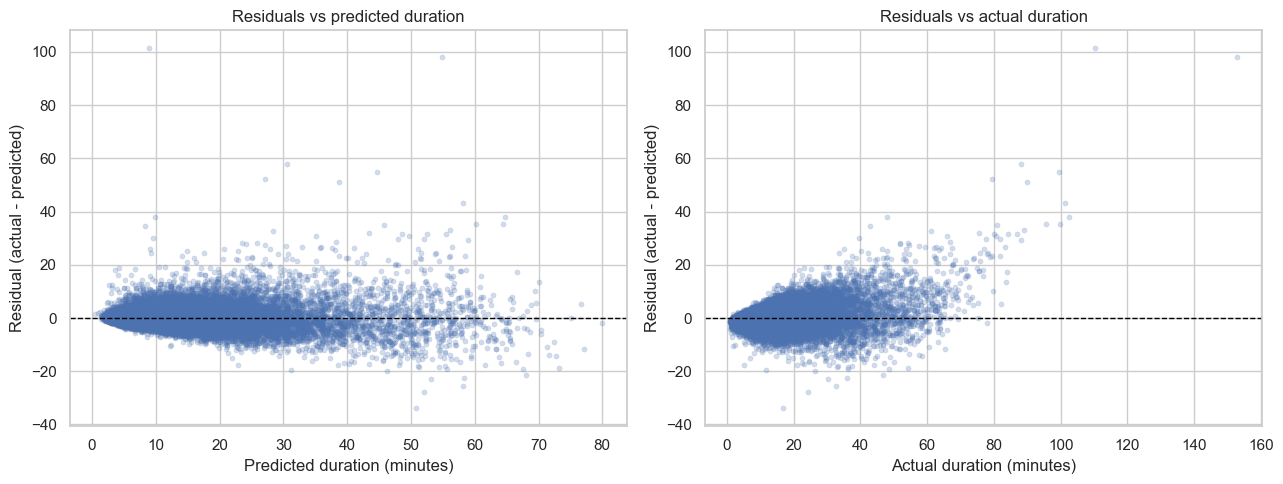

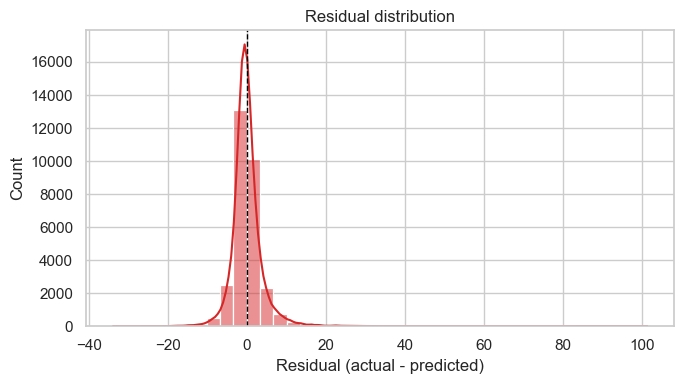

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=eval_results,
    x="predicted_duration_min",
    y="residual",
    s=14,
    alpha=0.25,
    edgecolor=None,
    ax=axes[0],
)
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Residuals vs predicted duration")
axes[0].set_xlabel("Predicted duration (minutes)")
axes[0].set_ylabel("Residual (actual - predicted)")

sns.scatterplot(
    data=eval_results,
    x="actual_duration_min",
    y="residual",
    s=14,
    alpha=0.25,
    edgecolor=None,
    ax=axes[1],
)
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Residuals vs actual duration")
axes[1].set_xlabel("Actual duration (minutes)")
axes[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(eval_results["residual"], bins=40, kde=True, color="#d62728")
plt.axvline(0, linestyle="--", color="black", linewidth=1)
plt.title("Residual distribution")
plt.xlabel("Residual (actual - predicted)")
plt.tight_layout()
plt.show()


### How to read the residual plot

- If the dots are randomly scattered around the zero line, the model errors are mostly random.
- If a visible pattern appears, the model is biased in those situations.
- The zero line is a useful reference because it marks perfect predictions.


In [5]:
worst20_underprediction_share = (worst20["residual"] > 0).mean()

print(
    "The residual cloud stays close to zero for many ordinary trips, but the spread gets wider as trip duration gets larger. "
    f"Many of the biggest outliers are positive residuals, and {worst20_underprediction_share:.0%} of the 20 largest errors are underpredictions."
)


The residual cloud stays close to zero for many ordinary trips, but the spread gets wider as trip duration gets larger. Many of the biggest outliers are positive residuals, and 95% of the 20 largest errors are underpredictions.


## Pattern and bias checks

To keep the grouping logic simple and easy to defend:

- **Rush hour vs non-rush hour:** use the engineered `is_rush_hour` flag when available. In the project feature engineering, rush hour means pickups from **7-9 AM** or **5-7 PM**.
- **Short vs long trips:** use the engineered `distance_category` when available, where **short = 0-2 miles**, **medium = 2-5 miles**, and **long = 5+ miles**.


Rush hour vs non-rush hour
rush_hour_group  trips  mean_actual  mean_predicted   mae  rmse  mean_residual  median_abs_error
  Non-rush hour  20359       14.261          14.280 2.527 3.992         -0.019             1.689
      Rush hour   9641       13.767          13.767 2.450 3.686         -0.001             1.674

Trip length groups
trip_length_group  trips  mean_actual  mean_predicted   mae  rmse  mean_residual  median_abs_error
            short  18302     8.618000        8.607000 1.793 2.632          0.011             1.339
           medium   7424    17.305000       17.360001 2.826 3.864         -0.055             2.180
             long   4274    32.023998       32.068001 4.974 7.139         -0.044             3.618



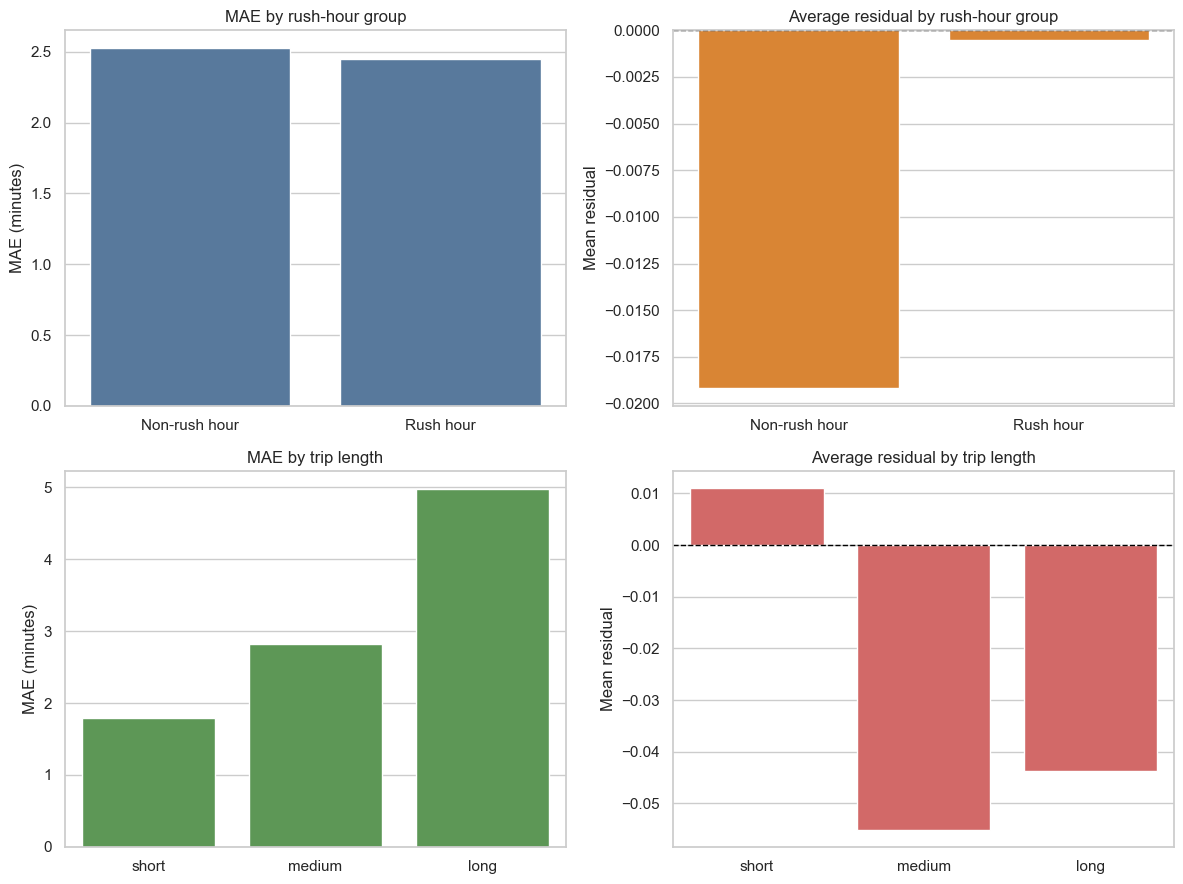

In [6]:
print("Rush hour vs non-rush hour")
print(rush_summary.round(3).to_string(index=False))
print()
print("Trip length groups")
print(distance_summary.round(3).to_string(index=False))
print()
distance_plot_order = [group for group in ["short", "medium", "long"] if group in distance_summary["trip_length_group"].tolist()]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=rush_summary, x="rush_hour_group", y="mae", color="#4c78a8", ax=axes[0, 0])
axes[0, 0].set_title("MAE by rush-hour group")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("MAE (minutes)")

sns.barplot(data=rush_summary, x="rush_hour_group", y="mean_residual", color="#f58518", ax=axes[0, 1])
axes[0, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0, 1].set_title("Average residual by rush-hour group")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Mean residual")

sns.barplot(
    data=distance_summary[distance_summary["trip_length_group"].isin(distance_plot_order)],
    x="trip_length_group",
    y="mae",
    order=distance_plot_order,
    color="#54a24b",
    ax=axes[1, 0],
)
axes[1, 0].set_title("MAE by trip length")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("MAE (minutes)")

sns.barplot(
    data=distance_summary[distance_summary["trip_length_group"].isin(distance_plot_order)],
    x="trip_length_group",
    y="mean_residual",
    order=distance_plot_order,
    color="#e45756",
    ax=axes[1, 1],
)
axes[1, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1, 1].set_title("Average residual by trip length")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean residual")

plt.tight_layout()
plt.show()


In [7]:
rush_mae = rush_summary.loc[rush_summary["rush_hour_group"] == "Rush hour", "mae"].iloc[0]
non_rush_mae = rush_summary.loc[rush_summary["rush_hour_group"] == "Non-rush hour", "mae"].iloc[0]

short_mae = distance_summary.loc[distance_summary["trip_length_group"] == "short", "mae"].iloc[0]
long_mae = distance_summary.loc[distance_summary["trip_length_group"] == "long", "mae"].iloc[0]

print(
    f"The rush-hour comparison does not show a major performance drop in this sample. MAE is {rush_mae:.2f} minutes during rush hour versus {non_rush_mae:.2f} minutes outside rush hour."
)
print(
    f"Trip length matters much more. MAE rises from {short_mae:.2f} minutes on short trips to {long_mae:.2f} minutes on long trips, so the model is much more reliable on ordinary short rides than on long rides."
)


The rush-hour comparison does not show a major performance drop in this sample. MAE is 2.45 minutes during rush hour versus 2.53 minutes outside rush hour.
Trip length matters much more. MAE rises from 1.79 minutes on short trips to 4.97 minutes on long trips, so the model is much more reliable on ordinary short rides than on long rides.


## Worst prediction cases

The table below shows the trips with the largest **absolute errors**. These are useful because they show where average metrics hide the model's biggest misses.


In [8]:
worst_case_columns = [
    "row_id",
    "actual_duration_min",
    "predicted_duration_min",
    "residual",
    "abs_error",
    "trip_distance",
    "trip_length_group",
    "pickup_hour",
    "rush_hour_group",
    "pickup_borough",
    "dropoff_borough",
    "is_airport_trip",
    "is_same_borough",
]

worst_cases_display = worst_cases[worst_case_columns].round(2)
print(worst_cases_display.to_string(index=False))
print()

worst20_long_share = (worst20["trip_length_group"] == "long").mean()
worst20_airport_share = worst20["is_airport_trip"].mean() if "is_airport_trip" in worst20.columns else np.nan
worst20_rush_share = (worst20["rush_hour_group"] == "Rush hour").mean()
worst20_actual_mean = worst20["actual_duration_min"].mean()
worst20_pred_mean = worst20["predicted_duration_min"].mean()

if "borough_route" in worst20.columns:
    top_routes = worst20["borough_route"].value_counts().head(3)
    route_text = ", ".join([f"{route} ({count})" for route, count in top_routes.items()])
else:
    route_text = "route information was not available"

print(
    f"Most of the biggest misses are underpredictions. The 20 worst cases average {worst20_actual_mean:.1f} actual minutes but only {worst20_pred_mean:.1f} predicted minutes."
)
print(
    f"Among the 20 worst errors, {worst20_long_share:.0%} are long trips and {worst20_airport_share:.0%} involve an airport. Only {worst20_rush_share:.0%} happen during rush hour."
)
print(
    f"The most common borough routes in the worst cases are {route_text}. In plain English, the model seems to struggle most when a trip turns into an unusually long Queens/Manhattan or airport-related ride."
)


 row_id  actual_duration_min  predicted_duration_min   residual  abs_error  trip_distance trip_length_group  pickup_hour rush_hour_group pickup_borough dropoff_borough  is_airport_trip  is_same_borough
  69573           110.300003                8.970000 101.330002 101.330002       1.600000             short           23   Non-rush hour      Manhattan       Manhattan                0                1
 172395           152.830002               54.830002  98.000000  98.000000      18.330000              long           12   Non-rush hour      Manhattan       Manhattan                0                1
1549760            88.220001               30.520000  57.700001  57.700001       5.610000              long           16   Non-rush hour      Manhattan          Queens                1                0
1812716            99.650002               44.730000  54.919998  54.919998      24.920000              long            6   Non-rush hour         Queens       Manhattan                0        